In [117]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split

from skimage.feature import hog
from skimage import exposure

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


## data loading and splitting

In [128]:
def plot_histogram_comparison(X, y, n=4, seed=42):
    """Plot images alongside their histograms, color coded by label."""
    rng = np.random.RandomState(seed)
    indices = rng.choice(len(X), size=n, replace=False)

    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    for i, idx in enumerate(indices):
        label = "Tumor" if y[idx] == 1 else "No Tumor"
        color = 'red' if y[idx] == 1 else 'blue'

        axes[i, 0].imshow(X[idx], cmap='gray')
        axes[i, 0].set_title(label)
        axes[i, 0].axis('off')

        axes[i, 1].hist(X[idx].flatten(), bins=256, color=color, alpha=0.7)
        axes[i, 1].set_title(f"{label} Histogram")
        axes[i, 1].set_xlabel("Pixel Intensity")
        axes[i, 1].set_ylabel("Count")

    plt.suptitle("Images and Histograms", fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_pipeline_steps(X_raw, X_bg, X_clahe, X_blur, X_hog, y, idx=0):
    """Show all preprocessing steps for one image side by side."""
    label = "Tumor" if y[idx] == 1 else "No Tumor"
    steps = [
        (X_raw[idx],   "1. Original"),
        (X_clahe[idx], "3. CLAHE"),
        (X_blur[idx],  "4. Gaussian Blur"),
        (X_hog[idx],   "5. HOG Features"),
    ]

    fig, axes = plt.subplots(1, len(steps), figsize=(21, 4))
    fig.suptitle(f"Preprocessing Pipeline — {label}", fontsize=13)
    for ax, (img, title) in zip(axes, steps):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, labels=['No Tumor', 'Tumor']):
    """Plot styled confusion matrix."""
    from sklearn.metrics import ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix", fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_pca_variance(pca):
    """Show how many components explain how much variance."""
    cumulative = np.cumsum(pca.explained_variance_ratio_)

    plt.figure(figsize=(8, 4))
    plt.plot(cumulative, color='royalblue', linewidth=2)
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("PCA — How Many Components Do We Need?")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Components to explain 95% variance: {pca.n_components_}")

In [86]:
def load_and_prepare(dataset_dir, image_size=(256, 256)):

    X = []
    y = []

    for label, folder in [(1, "yes"), (0, "no")]:
        folder_path = os.path.join(dataset_dir, folder)
        for fname in os.listdir(folder_path):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                path = os.path.join(folder_path, fname)
                img = cv2.imread(path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                img = cv2.resize(img, image_size)
                X.append(img)
                y.append(label)

    return np.array(X), np.array(y)

In [87]:
X, y = load_and_prepare(r"C:\Users\ahmed_abdulhakeem\Downloads\brain-tumer-classification\big-data")

In [88]:
X.shape, y.shape

((3000, 256, 256), (3000,))

In [89]:
def remove_background(img):
    _, mask = cv2.threshold(img, 10, 255, cv2.THRESH_BINARY)
    return cv2.bitwise_and(img, img, mask=mask)

def apply_clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(img)

def apply_blur(img):
    return cv2.GaussianBlur(img, (5, 5), 0)

def extract_hog(img):
    features, hog_img = hog(
        img,
        orientations=9,        # 9 direction bins (0° to 180°)
        pixels_per_cell=(8,8), # each cell is 8x8 pixels
        cells_per_block=(2,2), # normalize over 2x2 cells
        visualize=True         # also return visual image
    )
    return features, hog_img

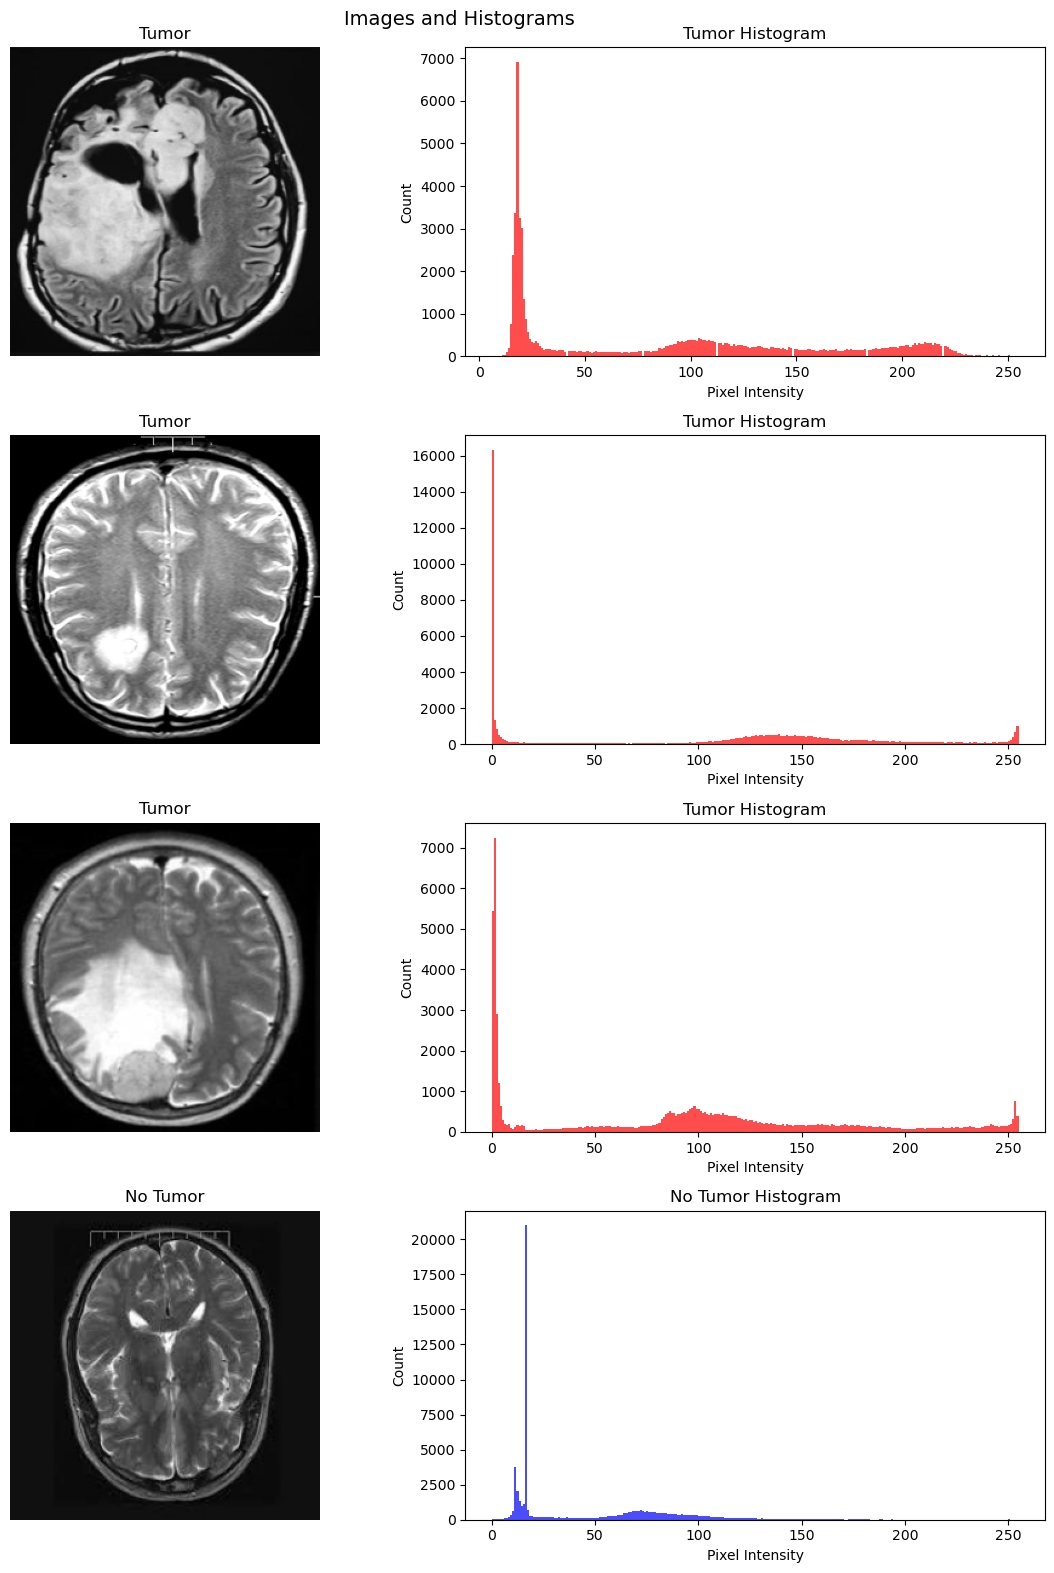

In [90]:
plot_histogram_comparison(X, y, n=4, seed=2)

In [ ]:
X_no_bg = np.array([remove_background(img) for img in X])
X_clahe = np.array([apply_clahe(img) for img in X_no_bg])
X_hog = [extract_hog(img) for img in X_clahe]
X_features = np.array([feat for feat, _ in X_hog])
X_imgs = np.array([hog_img for _, hog_img in X_hog])

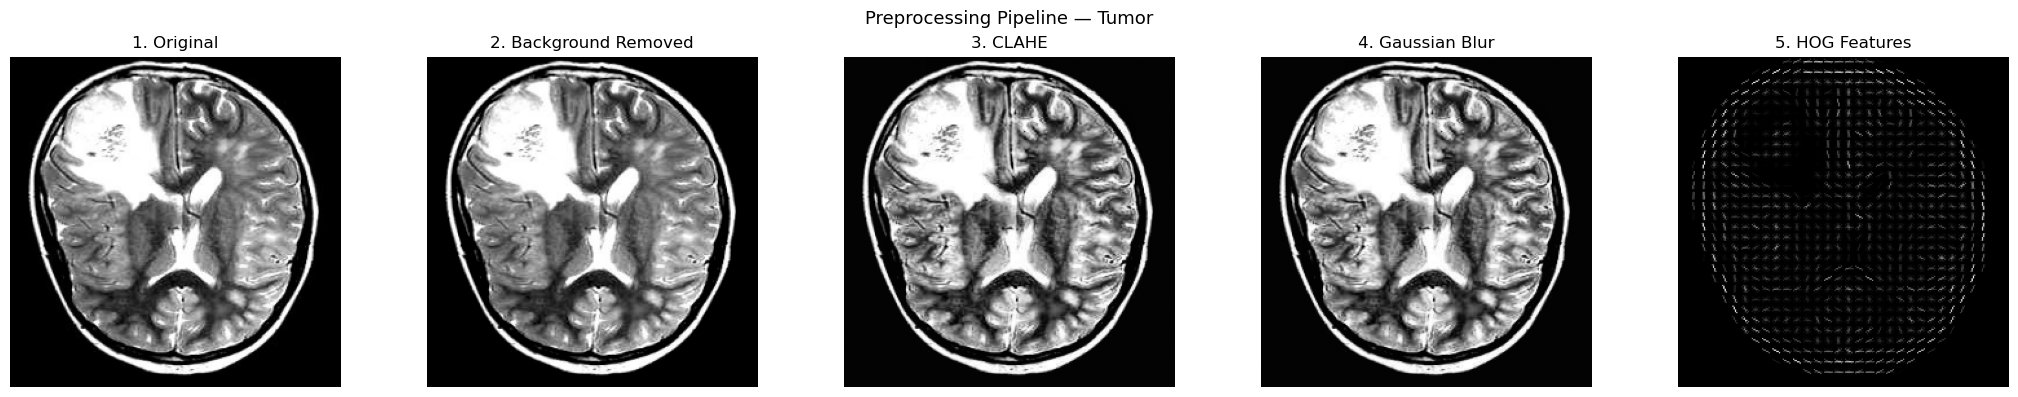

In [ ]:
plot_pipeline_steps(X, X_no_bg, X_clahe, X_imgs, y, idx=0)

In [94]:
print(f"Feature matrix shape: {X_features.shape}")

Feature matrix shape: (3000, 34596)


In [109]:
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2400, 34596), (2400,), (600, 34596), (600,))

In [135]:
# 1. Scale first (important for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. PCA - keep 95% of variance
pca = PCA(n_components=40, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Before PCA: {X_train_scaled.shape[1]} features")
print(f"After PCA:  {X_train_pca.shape[1]} features")

Before PCA: 34596 features
After PCA:  40 features


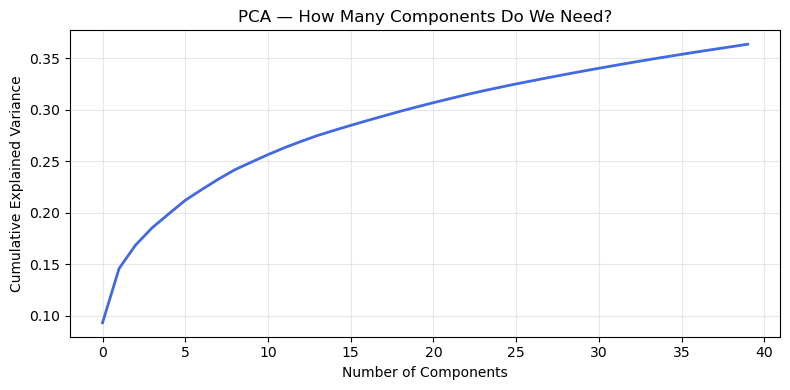

Components to explain 95% variance: 40
explained_variance: 0.3636


In [136]:
plot_pca_variance(pca)
explained_variance = pca.explained_variance_ratio_

print(f"explained_variance: {sum(explained_variance):.4f}")

Accuracy: 0.9971
              precision    recall  f1-score   support

    No Tumor       1.00      1.00      1.00      1200
       Tumor       1.00      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



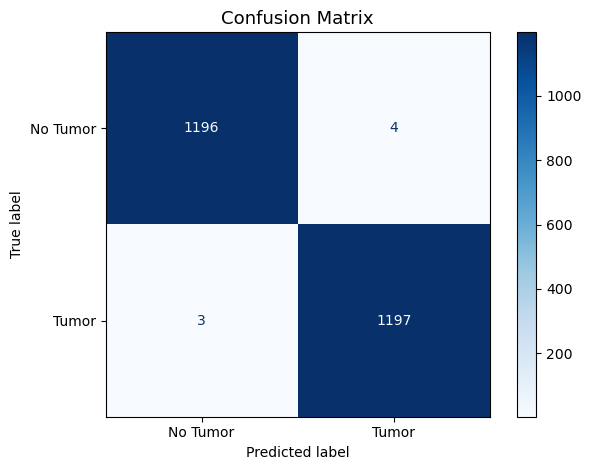

In [137]:
# Train SVM
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_pca, y_train)

# Predict
y_pred = svm.predict(X_train_pca)

# Results
print(f"Accuracy: {accuracy_score(y_train, y_pred):.4f}")
print(classification_report(y_train, y_pred, target_names=['No Tumor', 'Tumor']))

plot_confusion_matrix(confusion_matrix(y_train, y_pred), labels=['No Tumor', 'Tumor'])

Accuracy: 0.9817
              precision    recall  f1-score   support

    No Tumor       0.99      0.97      0.98       300
       Tumor       0.97      0.99      0.98       300

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



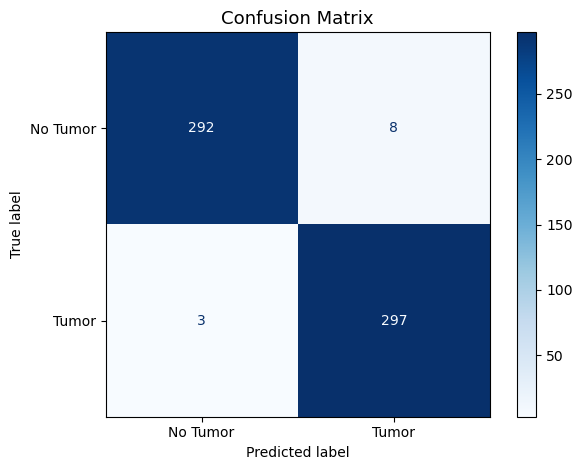

In [138]:
# Predict
y_pred = svm.predict(X_test_pca)

# Results
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['No Tumor', 'Tumor']))

plot_confusion_matrix(confusion_matrix(y_test, y_pred), labels=['No Tumor', 'Tumor'])